# <center> Tutorial 1 </center>

In [43]:
#!pip install pennylane
import pennylane as qml
import numpy as np

---
## <span style="color:navy"> **1.Installation** </span>


### <span style="color:gold"> **1-1 provided by K-Q (Unavailable Yet)** </span>

In [2]:
#!pip install pennylane-kq

In [3]:
accessKeyId = "D5AVMBO0US0XTOINTH46Y431Z9O3E0VV"
secretAccessKey = "zt7cqoj4H0y4ilrOIevDkPRKGMCTvpZGIlbtC/LefW8="

dev = qml.device("kq.emulator", wires=2, #shots=2048, 
                accessKeyId = accessKeyId,
                secretAccessKey = secretAccessKey,
                ) 

### 1-2 provided by PENNYLANE (Built-in)

In [4]:
dev = qml.device("default.qubit", wires=2, shots=2048)

---
## <span style="color:navy"> **2. 실습을 통한 양자회로 이해: 선형대수 v.s. 양자회로** </span>

### <span style="color:gold"> **2-1 Dirac Notation and Mathematical Expression** </span>

![](images/schodinger_cat.png)

$$|\text{Alive}\rangle = \begin{pmatrix}
1 \\ 0
\end{pmatrix} \quad \text{and} \quad |\text{Dead}\rangle = \begin{pmatrix}
0 \\ 1 
\end{pmatrix}
$$

$$
|\psi\rangle = \alpha |\text{Alive}\rangle + \beta |\text{Dead}\rangle = \begin{pmatrix}
\alpha \\ \beta
\end{pmatrix}, \, \text{where} \, \alpha,\beta \in \mathbb{C}
$$



$$
\langle \psi | \psi \rangle = (|\psi\rangle)^\dagger \cdot |\psi\rangle = \begin{pmatrix}\alpha^\ast &\beta^\ast\end{pmatrix} \cdot \begin{pmatrix}\alpha\\ \beta \end{pmatrix} = |\alpha|^2 + |\beta|^2 = 1
$$

Outcome: "Alive" $\Longrightarrow$ $\text{Pr}(\text{Alive}) = |\langle \text{Alive}  | \psi \rangle|^2 = |\alpha|^2$ <br>
Outcome: "Dead" $\Longrightarrow$ $\text{Pr}(\text{Dead}) = |\langle \text{Dead} | \psi \rangle|^2 = |\beta|^2$ 

### <span style="color:gold"> **2-2 Quantum Bit(=Qubit) and Single-qubit Gates** </span>

#### **Quantum State of a qubit**

![](images/qubit.png)

$|\psi\rangle = \cos(\theta/2) |0\rangle + e^{i\varphi}\sin(\theta/2) |1\rangle $, where $0\le\theta < \pi$ and $0\le\varphi < 2\pi$.

#### **Single-qubit Gates**

<img src="images/1Qgates1.png" width="40%" height="40%">

Examples

$X|0\rangle = |1\rangle$ <br>
$H|1\rangle = |-\rangle := (|0\rangle-|1\rangle) / \sqrt{2}$ <br>
$Z|-\rangle = |+\rangle := (|0\rangle+|1\rangle) / \sqrt{2}$ <br>
$Y|+\rangle = (-i|0\rangle+i|1\rangle) / \sqrt{2}$

In [ ]:
dev = qml.device("default.qubit", wires=1)
@qml.qnode(dev)
def circuit_1Qgates():
    qml.PauliX(wires=0)
    #qml.H(wires=0)
    #qml.PauliZ(wires=0)
    #qml.PauliY(wires=0)
    return qml.state()

circuit_1Qgates()

array([0.-0.70710678j, 0.+0.70710678j])

#### **Parametrized Single-qubit Gates**

<img src="images/1Qgates2.png" width="60%" height="60%">

In [50]:
@qml.qnode(dev)
def circuit_1Qstate(theta, phi):
    qml.RY(phi=theta, wires=0)
    qml.RZ(phi=phi, wires=0)
    return qml.state()

$R_z(\varphi)R_y(\theta)|0\rangle = e^{-i\varphi/2} \cos(\theta/2)|0\rangle + e^{i\varphi/2} \sin(\theta/2)|1\rangle$ <br>
$e^{i\varphi/2}R_z(\varphi)R_y(\theta)|0\rangle = \cos(\theta/2) |0\rangle + e^{i\varphi/2} \sin(\theta/2)|1\rangle$

In [ ]:
# |0> + i|1> / sqrt(2)
np.exp(1j*np.pi/4) * circuit_1Qstate(np.pi/2, np.pi/2) 

array([7.07106781e-01+0.j        , 1.11022302e-16+0.70710678j])

### <span style="color:gold"> **2-3 Two-qubit States & Two-qubit Gates** </span>

#### **Two-qubit State**

$|\psi_1\rangle = a|0\rangle + b|1\rangle$ and $|\psi_2\rangle = c|0\rangle + d|1\rangle$


$|\Psi\rangle = |\psi_1\rangle|\psi_2\rangle = (a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle)=ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle=\begin{pmatrix} ac\\ad\\bc\\bd \end{pmatrix}$<br>

Check: $(Y\otimes X)|\Psi\rangle = (Y|\psi_1\rangle)\otimes (X|\psi_2\rangle)$

#### **Two-qubit Gates**<br>

<img src="images/2Qgates.png" width="60%" height="60%">

<img src="images/su4gate.png" width="60%" height="60%">

#### **Two-qubit Separable and Entangled States**

$|\Psi\rangle$

Final example 
$|\Psi\rangle = \cos(\theta/2) |00\rangle + \sin(\theta/2) |11\rangle$

### <span style="color:gold"> **2-4 Multi-qubit Gates** </span>

Toffoli Gate

(<Figure size 500x500 with 1 Axes>, <Axes: >)

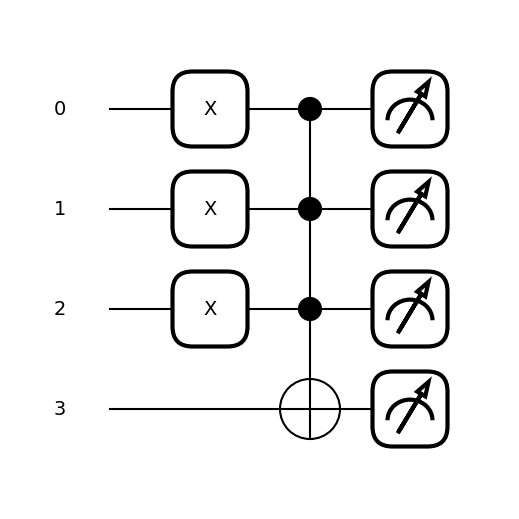

In [53]:
n_qubits = 4
dev2 = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev2)
def circuit_Toffoli(n_qubits):
    for i in range(n_qubits-1):
        qml.X(wires=i)
    qml.MultiControlledX(wires=range(n_qubits))
    return qml.state()
qml.draw_mpl(circuit_Toffoli)(n_qubits)

In [54]:
circuit_Toffoli(n_qubits)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j])

### <span style="color:gold"> **2-5 Measurement in the Quantum Circuit** </span>

Statevector랑 Count로 대체하기! <br>
그리고 return type에 따른 설명 진행하기

---

In [5]:
qml.PauliX(wires=0).matrix()

array([[0, 1],
       [1, 0]])

In [6]:
qml.CNOT(wires=[0,1]).matrix()

array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0]])

In [7]:
toffoli = qml.MultiControlledX(wires=[0,1,2])
toffoli.matrix()

array([[1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0.]])

### 2. Bell States

In [8]:
@qml.qnode(dev)
def circuit1():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.counts()

(<Figure size 500x300 with 1 Axes>, <Axes: >)

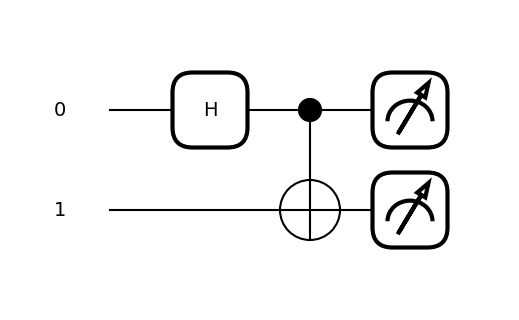

In [9]:
qml.draw_mpl(circuit1)()

In [10]:
result = circuit1()
print('Outcomes: Counts\n', result)

Outcomes: Counts
 {'00': tensor(1074, requires_grad=True), '11': tensor(974, requires_grad=True)}


In [11]:
@qml.qnode(dev)
def circuit2():
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.PauliX(wires=1)
    return qml.counts()

(<Figure size 700x300 with 1 Axes>, <Axes: >)

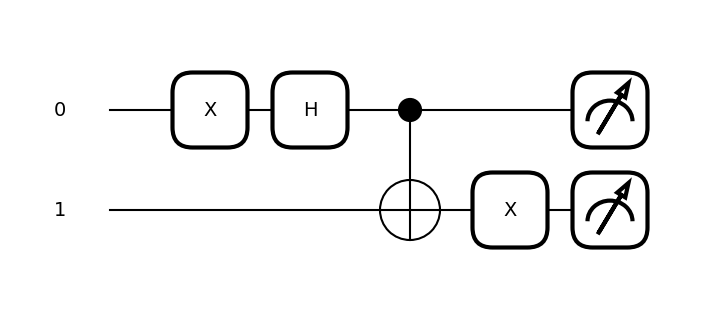

In [12]:
qml.draw_mpl(circuit2)()

In [13]:
result = circuit2()
print('Outcomes: Counts\n', result)

Outcomes: Counts
 {'01': tensor(1037, requires_grad=True), '10': tensor(1011, requires_grad=True)}


## Example 3 : Statevector
---

In [14]:
dev1 = qml.device("default.qubit", wires=2)

In [15]:
@qml.qnode(dev1)
def circuit3():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

In [16]:
circuit3()

tensor([0.70710678+0.j, 0.        +0.j, 0.        +0.j, 0.70710678+0.j], requires_grad=True)

In [17]:
@qml.qnode(dev1)
def circuit4():
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.PauliX(wires=1)
    return qml.state()

In [18]:
circuit4()

tensor([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
         0.        +0.j], requires_grad=True)

## Example 4 : Toffli Gate
---

Example

1. GHZ states?
2. CHSH game